In [ ]:
from PIL import Image
from pathlib import Path

def apply_sepia_filter(image_path, output_path):
    try:
        img = Image.open(image_path)
        width, height = img.size
        pixels = img.load()

        for py in range(height):
            for px in range(width):
                r, g, b = img.getpixel((px, py))

                new_r = int(0.393 * r + 0.769 * g + 0.189 * b)
                new_g = int(0.349 * r + 0.686 * g + 0.168 * b)
                new_b = int(0.272 * r + 0.534 * g + 0.131 * b)

                new_r = min(255, new_r)
                new_g = min(255, new_g)
                new_b = min(255, new_b)

                pixels[px, py] = (new_r, new_g, new_b)
        
        img.save(output_path)
        print(f"Sepia filter applied and image saved to {output_path}")

    except FileNotFoundError:
        print(f"Error: The file at {image_path} was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

folder = Path("data/classic")
save_folder = Path("data/sepia")
file_names = [f.name for f in folder.iterdir() if f.is_file()]

# for file_name in file_names:
    # apply_sepia_filter(folder / file_name, save_folder / ("Sepia_" + file_name))

Sepia filter applied and image saved to data\sepia\Sepia_Image_1 copy.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_1.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_10.jpeg
Sepia filter applied and image saved to data\sepia\Sepia_Image_10.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_11.jpeg
Sepia filter applied and image saved to data\sepia\Sepia_Image_11.JPG
Sepia filter applied and image saved to data\sepia\Sepia_Image_12 copy.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_12.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_13 copy.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_13.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_14 copy.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_14.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_15 copy.jpg
Sepia filter applied and image saved to data\sepia\Sepia_Image_15

In [84]:
import numpy as np

def load_data(classic_dir="data/classic", sepia_dir="data/sepia", image_size=(32, 32)):
    classic_dir = Path(classic_dir)
    sepia_dir = Path(sepia_dir)

    output_names = np.array(["no filter", "filter"])
    image_paths_labels = []

    for p in classic_dir.iterdir():
        if p.is_file():
            image_paths_labels.append((p, 0))

    for p in sepia_dir.iterdir():
        if p.is_file():
            image_paths_labels.append((p, 1))

    if len(image_paths_labels) == 0:
        raise ValueError("No images found in data/classic and data/sepia.")

    inputs = []
    outputs = []

    for img_path, label in image_paths_labels:
        img = Image.open(img_path).convert("RGB")
        img = img.resize(image_size)
        arr = np.array(img, dtype=np.float32)
        inputs.append(arr)
        outputs.append(label)

    inputs = np.array(inputs)
    outputs = np.array(outputs, dtype=np.int64)

    permutation = np.random.permutation(len(inputs))
    inputs = inputs[permutation]
    outputs = outputs[permutation]

    return inputs, outputs, output_names

inputs, outputs, output_names = load_data()

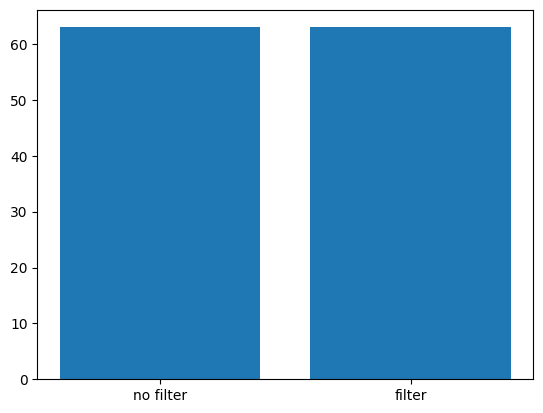

In [85]:
import matplotlib.pyplot as plt 

def split_data(inputs, outputs):
    np.random.seed(8)

    indexes = [i for i in range(len(inputs))]
    train_sample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    test_sample = [i for i in indexes if i not in train_sample]

    train_inputs = [inputs[i] for i in train_sample]
    train_outputs = [outputs[i] for i in train_sample]

    test_inputs = [inputs[i] for i in test_sample]
    test_outputs = [outputs[i] for i in test_sample]

    return train_inputs, train_outputs, test_inputs, test_outputs

train_inputs, train_outputs, test_inputs, test_outputs = split_data(inputs, outputs)

bins = range(len(output_names) + 1)
plt.hist(train_outputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), output_names)
plt.show()


In [86]:
from sklearn.preprocessing import StandardScaler

def normalisation(train_data, test_data):
    scaler = StandardScaler()

    scaler.fit(train_data)
    normalised_train_ddata = scaler.transform(train_data)
    normalised_test_data = scaler.transform(test_data) 
    
    return normalised_train_ddata, normalised_test_data

def flatten(mat):
    return np.array(mat, dtype=np.float32).reshape(-1)

train_inputs_flatten = [flatten(el) for el in train_inputs]
test_inputs_flatten = [flatten(el) for el in test_inputs]
train_inputs_normalised, test_inputs_normalised = normalisation(train_inputs_flatten, test_inputs_flatten)

Iteration 1, loss = 1.09942236
Iteration 2, loss = 0.96000323
Iteration 3, loss = 0.82087785
Iteration 4, loss = 0.71257170
Iteration 5, loss = 0.64194749
Iteration 6, loss = 0.59681365
Iteration 7, loss = 0.55567359
Iteration 8, loss = 0.51445468
Iteration 9, loss = 0.47193889
Iteration 10, loss = 0.43083196
Iteration 11, loss = 0.39376544
Iteration 12, loss = 0.36202747
Iteration 13, loss = 0.33525023
Iteration 14, loss = 0.31454589
Iteration 15, loss = 0.29797341
Iteration 16, loss = 0.28392993
Iteration 17, loss = 0.27108628
Iteration 18, loss = 0.25868553
Iteration 19, loss = 0.24661210
Iteration 20, loss = 0.23491771
Iteration 21, loss = 0.22386429
Iteration 22, loss = 0.21357390
Iteration 23, loss = 0.20429514
Iteration 24, loss = 0.19615399
Iteration 25, loss = 0.18868236
Iteration 26, loss = 0.18176136
Iteration 27, loss = 0.17532575
Iteration 28, loss = 0.16930135
Iteration 29, loss = 0.16383117
Iteration 30, loss = 0.15865833
Iteration 31, loss = 0.15375881
Iteration 32, los

d:\Facultate\Inteligenta artificiala\Laborator\Laborator 7\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


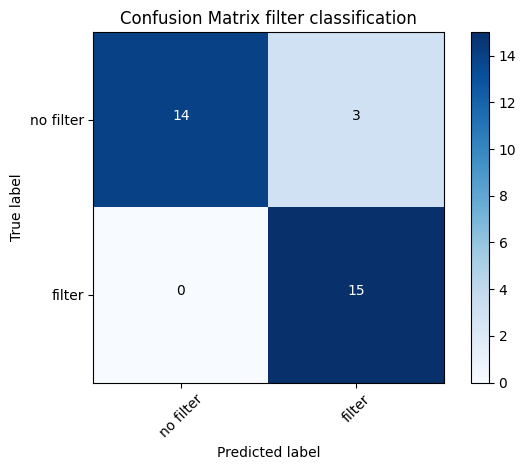

acc:  0.90625
precision:  {np.str_('no filter'): np.float64(1.0), np.str_('filter'): np.float64(0.8333333333333334)}
recall:  {np.str_('no filter'): np.float64(0.8235294117647058), np.str_('filter'): np.float64(1.0)}


In [94]:
from sklearn import neural_network
from sklearn.metrics import confusion_matrix

def evalMultiClass(realLabels, computedLabels, labelNames):
    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix

def plotConfusionMatrix(cm, classNames, title):
    import itertools 

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

classifier = neural_network.MLPClassifier(hidden_layer_sizes=(20,), activation='relu', max_iter=100, solver='sgd', verbose=10, random_state=1, learning_rate_init=0.001)

classifier.fit(train_inputs_normalised, train_outputs)

predictedLabels = classifier.predict(test_inputs_normalised)
acc, prec, recall, cm = evalMultiClass(np.array(test_outputs), predictedLabels, output_names)


plotConfusionMatrix(cm, output_names, "filter classification")
print('acc: ', acc)
print('precision: ', prec)
print('recall: ', recall)


In [88]:
def evaluate_parameters(configs):
    for config in configs:
        classifier = neural_network.MLPClassifier(
            hidden_layer_sizes=config["hidden_layers"], 
            activation='relu', 
            max_iter=config["max_iter"], 
            solver='sgd', 
            random_state=1, 
            learning_rate_init=config["lr"]
        )

        classifier.fit(train_inputs_normalised, train_outputs)

        predictedLabels = classifier.predict(test_inputs_normalised)
        acc, prec, recall, cm = evalMultiClass(np.array(test_outputs), predictedLabels, output_names)

        print(config)
        print('acc: ', acc)
        print('precision: ', prec)
        print('recall: ', recall)
        print('~~~~~~~~~~~~~~~')

configs = [
    {"hidden_layers": (5,), "lr": 0.01, "max_iter": 100},
    {"hidden_layers": (10,), "lr": 0.001, "max_iter": 200},
    {"hidden_layers": (100,), "lr": 0.001, "max_iter": 200},
    {"hidden_layers": (100,), "lr": 0.1, "max_iter": 100}
]

evaluate_parameters(configs)

{'hidden_layers': (5,), 'lr': 0.01, 'max_iter': 100}
acc:  0.9375
precision:  {np.str_('no filter'): np.float64(1.0), np.str_('filter'): np.float64(0.8823529411764706)}
recall:  {np.str_('no filter'): np.float64(0.8823529411764706), np.str_('filter'): np.float64(1.0)}
~~~~~~~~~~~~~~~


d:\Facultate\Inteligenta artificiala\Laborator\Laborator 7\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layers': (10,), 'lr': 0.001, 'max_iter': 200}
acc:  0.8125
precision:  {np.str_('no filter'): np.float64(0.8235294117647058), np.str_('filter'): np.float64(0.8)}
recall:  {np.str_('no filter'): np.float64(0.8235294117647058), np.str_('filter'): np.float64(0.8)}
~~~~~~~~~~~~~~~


d:\Facultate\Inteligenta artificiala\Laborator\Laborator 7\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layers': (100,), 'lr': 0.001, 'max_iter': 200}
acc:  0.90625
precision:  {np.str_('no filter'): np.float64(0.9375), np.str_('filter'): np.float64(0.875)}
recall:  {np.str_('no filter'): np.float64(0.8823529411764706), np.str_('filter'): np.float64(0.9333333333333333)}
~~~~~~~~~~~~~~~
{'hidden_layers': (100,), 'lr': 0.1, 'max_iter': 100}
acc:  0.90625
precision:  {np.str_('no filter'): np.float64(1.0), np.str_('filter'): np.float64(0.8333333333333334)}
recall:  {np.str_('no filter'): np.float64(0.8235294117647058), np.str_('filter'): np.float64(1.0)}
~~~~~~~~~~~~~~~


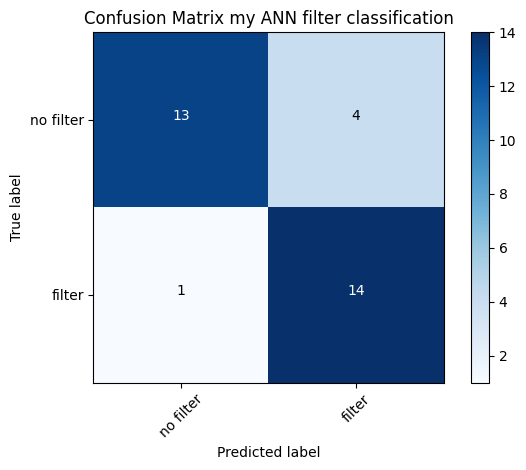

acc:  0.84375
precision:  {np.str_('no filter'): np.float64(0.9285714285714286), np.str_('filter'): np.float64(0.7777777777777778)}
recall:  {np.str_('no filter'): np.float64(0.7647058823529411), np.str_('filter'): np.float64(0.9333333333333333)}


In [89]:
class MyANN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, epochs=1000, seed=42):
        self.lr = lr
        self.epochs = epochs

        np.random.seed(seed)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, sigmoid_output):
        return sigmoid_output * (1 - sigmoid_output)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2

    def backward(self, X, y, m):
        dZ2 = self.A2 - y
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = np.dot(dZ2, self.W2.T) * self.sigmoid_derivative(self.A1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # update
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        m = X.shape[0]

        for epoch in range(self.epochs):
            self.forward(X)
            self.backward(X, y, m)

    def predict(self, X):
        X = np.array(X)
        probs = self.forward(X)
        return (probs >= 0.5).astype(int).flatten()

my_ann = MyANN(
    input_size=len(train_inputs_normalised[0]),
    hidden_size=10,
    output_size=1,
    lr=0.01,
    epochs=1000
)

my_ann.fit(train_inputs_normalised, train_outputs)

predictedLabels = my_ann.predict(test_inputs_normalised)
acc, prec, recall, cm = evalMultiClass(np.array(test_outputs), predictedLabels, output_names)


plotConfusionMatrix(cm, output_names, "my ANN filter classification")
print('acc: ', acc)
print('precision: ', prec)
print('recall: ', recall)

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(np.float32)

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, seed=1):
        rng = np.random.default_rng(seed)
        self.k = kernel_size
        self.out_channels = out_channels
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = rng.normal(0, scale, size=(out_channels, in_channels, kernel_size, kernel_size)).astype(np.float32)
        self.b = np.zeros((out_channels, 1), dtype=np.float32)

    def forward(self, x):
        self.x = x
        C, H, W = x.shape
        k = self.k
        H_out = H - k + 1
        W_out = W - k + 1
        out = np.zeros((self.out_channels, H_out, W_out), dtype=np.float32)

        for f in range(self.out_channels):
            for i in range(H_out):
                for j in range(W_out):
                    region = x[:, i:i+k, j:j+k]
                    out[f, i, j] = np.sum(region * self.W[f]) + self.b[f, 0]

        self.out = out
        return out

    def backward(self, d_out, lr):
        C, H, W = self.x.shape
        F, H_out, W_out = d_out.shape
        k = self.k

        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dx = np.zeros_like(self.x)

        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    region = self.x[:, i:i+k, j:j+k]
                    dW[f] += d_out[f, i, j] * region
                    dx[:, i:i+k, j:j+k] += d_out[f, i, j] * self.W[f]
                    db[f, 0] += d_out[f, i, j]

        self.W -= lr * dW
        self.b -= lr * db
        return dx

class MaxPool2x2:
    def __init__(self):
        self.size = 2

    def forward(self, x):
        self.x = x
        C, H, W = x.shape
        out_h = H // 2
        out_w = W // 2
        out = np.zeros((C, out_h, out_w), dtype=np.float32)
        self.mask = np.zeros_like(x, dtype=np.float32)

        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h0, h1 = 2*i, 2*i+2
                    w0, w1 = 2*j, 2*j+2
                    region = x[c, h0:h1, w0:w1]
                    max_idx = np.unravel_index(np.argmax(region), region.shape)
                    out[c, i, j] = region[max_idx]
                    self.mask[c, h0 + max_idx[0], w0 + max_idx[1]] = 1.0

        self.out = out
        return out

    def backward(self, d_out):
        C, out_h, out_w = d_out.shape
        dx = np.zeros_like(self.x, dtype=np.float32)

        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h0, h1 = 2*i, 2*i+2
                    w0, w1 = 2*j, 2*j+2
                    region_mask = self.mask[c, h0:h1, w0:w1]
                    dx[c, h0:h1, w0:w1] += d_out[c, i, j] * region_mask

        return dx

class Dense:
    def __init__(self, in_dim, out_dim, seed=1):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / in_dim)
        self.W = rng.normal(0, scale, size=(in_dim, out_dim)).astype(np.float32)
        self.b = np.zeros((1, out_dim), dtype=np.float32)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, d_out, lr):
        dW = self.x.T @ d_out
        db = np.sum(d_out, axis=0, keepdims=True)
        dx = d_out @ self.W.T

        self.W -= lr * dW
        self.b -= lr * db
        return dx

class MyCNNBinary:
    def __init__(self, in_channels=3, img_h=64, img_w=64, n_filters=8, kernel_size=3, lr=0.001, epochs=10, seed=1):
        self.lr = lr
        self.epochs = epochs

        self.conv = Conv2D(in_channels, n_filters, kernel_size, seed=seed)
        self.pool = MaxPool2x2()

        conv_h = img_h - kernel_size + 1
        conv_w = img_w - kernel_size + 1
        pool_h = conv_h // 2
        pool_w = conv_w // 2
        flat_dim = n_filters * pool_h * pool_w

        self.fc = Dense(flat_dim, 1, seed=seed+1)

    def forward(self, x):
        z1 = self.conv.forward(x)
        a1 = relu(z1)
        p1 = self.pool.forward(a1)
        self.p1_shape = p1.shape

        flat = p1.reshape(1, -1)
        z2 = self.fc.forward(flat)
        y_hat = sigmoid(z2)  

        self.z1 = z1
        self.a1 = a1
        self.p1 = p1
        self.flat = flat
        self.y_hat = y_hat
        return y_hat

    def backward(self, y_true):
        y = np.array([[y_true]], dtype=np.float32)

        dz2 = self.y_hat - y 
        dflat = self.fc.backward(dz2, self.lr)  
        dp1 = dflat.reshape(self.p1_shape)      

        da1 = self.pool.backward(dp1)
        dz1 = da1 * relu_deriv(self.z1)
        _ = self.conv.backward(dz1, self.lr)

    def fit(self, X, y, verbose=True):
        N = X.shape[0]
        for ep in range(self.epochs):
            idx = np.random.permutation(N)
            Xs = X[idx]
            ys = y[idx]

            loss_sum = 0.0
            correct = 0

            for i in range(N):
                y_hat = self.forward(Xs[i])
                p = float(np.clip(y_hat[0, 0], 1e-9, 1 - 1e-9))
                yi = float(ys[i])
                loss = -(yi * np.log(p) + (1 - yi) * np.log(1 - p))
                loss_sum += loss

                pred = 1 if p >= 0.5 else 0
                if pred == int(yi):
                    correct += 1

                self.backward(ys[i])

            if verbose:
                print(f"Epoch {ep+1}/{self.epochs} | loss={loss_sum/N:.4f} | acc={correct/N:.4f}")

    def predict(self, X):
        preds = []
        for i in range(X.shape[0]):
            p = float(self.forward(X[i])[0, 0])
            preds.append(1 if p >= 0.5 else 0)
        return np.array(preds, dtype=np.int64)

Epoch 1/8 | loss=0.6554 | acc=0.6111
Epoch 2/8 | loss=0.6120 | acc=0.5476
Epoch 3/8 | loss=0.5823 | acc=0.5794
Epoch 4/8 | loss=0.5599 | acc=0.6349
Epoch 5/8 | loss=0.5396 | acc=0.6667
Epoch 6/8 | loss=0.5208 | acc=0.6905
Epoch 7/8 | loss=0.5037 | acc=0.6984
Epoch 8/8 | loss=0.4869 | acc=0.7302


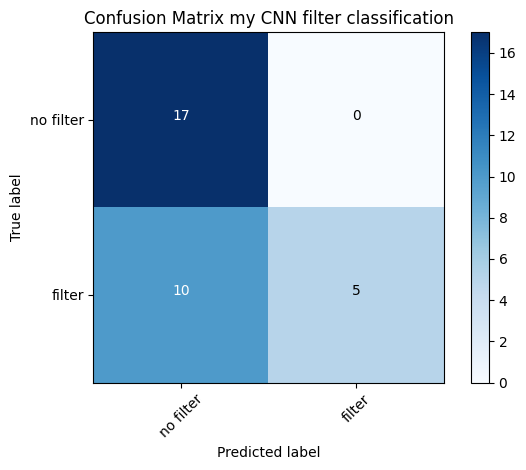

acc:  0.6875
precision:  {np.str_('no filter'): np.float64(0.6296296296296297), np.str_('filter'): np.float64(1.0)}
recall:  {np.str_('no filter'): np.float64(1.0), np.str_('filter'): np.float64(0.3333333333333333)}


In [ ]:
X_train = np.array(train_inputs, dtype=np.float32) / 255.0
X_test = np.array(test_inputs, dtype=np.float32) / 255.0

X_train = np.transpose(X_train, (0, 3, 1, 2))
X_test = np.transpose(X_test, (0, 3, 1, 2))

y_train = np.array(train_outputs, dtype=np.int64)
y_test = np.array(test_outputs, dtype=np.int64)

my_cnn = MyCNNBinary(
    in_channels=3,
    img_h=32,
    img_w=32,
    n_filters=4,
    kernel_size=3,
    lr=0.001,
    epochs=8,
    seed=1
)

my_cnn.fit(X_train, y_train, verbose=True)

predictedLabels = my_cnn.predict(X_test)
acc, prec, recall, cm = evalMultiClass(y_test, predictedLabels, output_names)

plotConfusionMatrix(cm, output_names, "my CNN filter classification")
print("acc: ", acc)
print("precision: ", prec)
print("recall: ", recall)